In [3]:
#Exercise 7.1

# Daily time (in hours): [study, entertainment, sleep]
time_data = [
 (3.5, 2.0, 7.0), (5.0, 1.5, 6.5), (2.5, 3.0, 8.0),
 (4.0, 2.0, 6.0), (1.5, 4.5, 9.0), (3.0, 2.5, 7.5),
 (5.5, 1.0, 6.0), (2.0, 3.5, 8.5), (4.5, 2.0, 7.0),
 (3.0, 3.0, 7.5), (6.0, 1.5, 6.0), (2.5, 4.0, 8.0),
 (4.0, 2.5, 7.0), (5.0, 2.0, 6.5), (3.5, 2.5, 7.0)
 ]

#Task 1
low=[]
moderate=[]
high=[]

for i in time_data:
  study_time=i[0]
  if study_time<3:
    low.append(study_time)
  elif 3<=study_time<=5:
    moderate.append(study_time)
  else:
    high.append(study_time)

print("Low study time:", low)
print("Moderate study time:", moderate)
print("High study time:", high)

Low study time: [2.5, 1.5, 2.0, 2.5]
Moderate study time: [3.5, 5.0, 4.0, 3.0, 4.5, 3.0, 4.0, 5.0, 3.5]
High study time: [5.5, 6.0]


In [5]:
#Task 2
print(f"Days having low study time: {len(low)}")
print(f"Days having moderate study time: {len(moderate)}")
print(f"Days having high study time: {len(high)}")

Days having low study time: 4
Days having moderate study time: 9
Days having high study time: 2


In [7]:
#Task 3
study_min=[]
for i in time_data:
  study_time=i[0]
  study_min.append(study_time*60)

print(study_min)

[210.0, 300.0, 150.0, 240.0, 90.0, 180.0, 330.0, 120.0, 270.0, 180.0, 360.0, 150.0, 240.0, 300.0, 210.0]


In [9]:
#Task 4
study_hours=[]
entertainment_hours=[]
sleep_hours=[]
for i in time_data:
  study_hours.append(i[0])
  entertainment_hours.append(i[1])
  sleep_hours.append(i[2])

avg_study=sum(study_hours)/len(study_hours)
avg_entertainment=sum(entertainment_hours)/len(entertainment_hours)
avg_sleep=sum(sleep_hours)/len(sleep_hours)

print(f"Average study hours: {avg_study}")
print(f"Average entertainment hours: {avg_entertainment}")
print(f"Average sleep hours: {avg_sleep}")

Average study hours: 3.7
Average entertainment hours: 2.5
Average sleep hours: 7.166666666666667


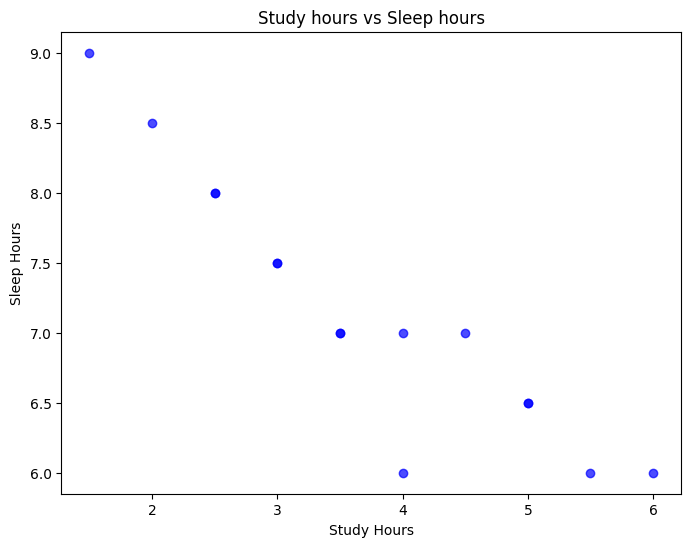

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(study_hours, sleep_hours, color='blue', alpha=0.7)
plt.xlabel('Study Hours')
plt.ylabel('Sleep Hours')
plt.title('Study hours vs Sleep hours')
plt.show()

In [23]:
# Exercise 8.1

# Task 1
def sum_nested_list(nested_list):
    total = 0
    for element in nested_list:
        if isinstance(element, list):
            total += sum_nested_list(element)
        else:
            total += element
    return total

test = [1, [2, [3, 4], 5], 6, [7, 8]]
print(sum_nested_list(test))

36


In [26]:
#Task 2
def generate_permutations(s):
    if len(s) <= 1:
        return [s]

    perms = []
    for i, char in enumerate(s):

        remaining = s[:i] + s[i+1:]

        for p in generate_permutations(remaining):
            perms.append(char + p)

    return perms

print(generate_permutations("abc"))
print(generate_permutations("aab"))

['abc', 'acb', 'bac', 'bca', 'cab', 'cba']
['aab', 'aba', 'aab', 'aba', 'baa', 'baa']


In [28]:
#Task 3
directory_structure = {
 "file1.txt": 200,
 "file2.txt": 300,
 "subdir1": {
 "file3.txt": 400,
 "file4.txt": 100
 },
 "subdir2": {
 "subsubdir1": {
 "file5.txt": 250
 },
 "file6.txt": 150
 }
}

def calculate_directory_size(directory):
    total_size = 0

    for key, value in directory.items():
        if isinstance(value, dict):
            total_size += calculate_directory_size(value)
        else:
            total_size += value
    return total_size

print(f"Total directory size: {calculate_directory_size(directory_structure)} KB")

Total directory size: 1400 KB


In [5]:
#Exercise 8.2

#Task 1
def min_coins(coins, amount):
  dp = [float('inf')] * (amount + 1)
  dp[0] = 0

  for coin in coins:
    for i in range(coin, amount + 1):
      dp[i] = min(dp[i], dp[i - coin] + 1)

  return dp[amount] if dp[amount] != float('inf') else -1

coins = [1, 2, 5]
amount = 11
print(f"Minimum coins needed for {amount}: {min_coins(coins, amount)}")

Minimum coins needed for 11: 3


In [6]:
#Task 2
def longest_common_subsequence(s1, s2):
  m, n = len(s1), len(s2)
  dp = [[0] * (n + 1) for _ in range(m + 1)]

  for i in range(1, m + 1):
    for j in range(1, n + 1):
      if s1[i-1] == s2[j-1]:
        dp[i][j] = dp[i-1][j-1] + 1
      else:
        dp[i][j] = max(dp[i-1][j], dp[i][j-1])

  return dp[m][n]

s1, s2 = "abcde", "ace"
print(f"LCS length of '{s1}' and '{s2}': {longest_common_subsequence(s1, s2)}")

LCS length of 'abcde' and 'ace': 3


In [9]:
#Task 3
def knapsack(weights, values, capacity):
  n = len(weights)
  dp = [[0] * (capacity + 1) for _ in range(n + 1)]

  for i in range(1, n + 1):
    for w in range(1, capacity + 1):
      if weights[i-1] <= w:
        dp[i][w] = max(dp[i-1][w], values[i-1] + dp[i-1][w - weights[i-1]])
      else:
        dp[i][w] = dp[i-1][w]

  return dp[n][capacity]

weights = [1, 3, 4, 5]
values = [1, 4, 5, 7]
capacity = 7
print(f"Maximum value in knapsack: {knapsack(weights, values, capacity)}")  # Output: 9

Maximum value in knapsack: 9
